In [1]:
import json
import math
import os
import time
import pickle as pkl

import numpy as np
import torch

import sklearn
import sklearn.metrics

import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.CMS)
plt.rcParams.update({"font.size": 20})

class print_color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as tr

import torch_geometric
from torch_geometric.nn import global_mean_pool
from torch_geometric.data import Batch
from torch_geometric.nn.conv import MessagePassing, GravNetConv
from torch_geometric.loader import DataLoader

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# import relevant functions from mlpf.pyg
import sys
sys.path.append("/home/jovyan/particleflow/mlpf/pyg/")

from PFDataset import PFDataset, PFDataLoader, Collater, InterleavedIterator
from utils import unpack_predictions, unpack_target, X_FEATURES, Y_FEATURES

In [4]:
# define the global base device
world_size = 1
if torch.cuda.device_count():
    device = torch.device("cuda:0")
    print(f"Will use {torch.cuda.get_device_name(device)}")
else:
    device = "cpu"
    print("Will use cpu")

Will use NVIDIA GeForce GTX 1080 Ti


# CLIC dataset

In [5]:
! ls /pfvol/tensorflow_datasets/clic*

/pfvol/tensorflow_datasets/clic_edm_qq_pf:
1.5.0

/pfvol/tensorflow_datasets/clic_edm_ttbar_pf:
1.5.0

/pfvol/tensorflow_datasets/clic_edm_ttbar_pu10_pf:
1.5.0

/pfvol/tensorflow_datasets/clic_edm_ww_fullhad_pf:
1.5.0

/pfvol/tensorflow_datasets/clic_edm_zh_tautau_pf:
1.5.0


In [6]:
data_dir = "/pfvol/tensorflow_datasets/"

In [42]:
def get_dataloaders(dataconfig, batch_size=10, num_workers=0, prefetch_factor=None):    
    """
    Takes a dataconfig [dict] and return respective dataloaders 
    for both VICreg (train/test) and downstream (train/test).
    
    Returns
        loader [dict]: {
                        "Vicreg": {"train": DataLoader, "test": DataLoader},
                        "downstream": {"train": DataLoader, "test": DataLoader},
                        } 
    """
    
    if (num_workers > 0) and (prefetch_factor is None):
        prefetch_factor = 2  # default prefetch_factor when num_workers>0

    
    loader = {
        "VICReg": {
            "train": [],
            "test": [],
        },
        "downstream": {
            "train": [],
            "test": [],
        },
    }

    print(print_color.BOLD + "VICReg dataset:" + print_color.END)    
    for split in ["train", "test"]:
        print(f"\t{split} dataset")
        dataset = []
        for physics_sample in dataconfig["VICReg"][split]:

            ds = torch.utils.data.Subset(
                PFDataset(data_dir, f"{physics_sample}:1.5.0", split).ds, 
                range(0, dataconfig["VICReg"][split][physics_sample]),
            )
            print(f"\t\t{physics_sample}: {len(ds)}")
            dataset.append(ds)
            
        dataset = torch.utils.data.ConcatDataset(dataset)

        loader["VICReg"][split] = PFDataLoader(
                dataset,
                batch_size=batch_size,
                collate_fn=Collater(["X", "ygen", "ycand"],  pad_3d=False),
                sampler=torch.utils.data.RandomSampler(ds),
                num_workers=num_workers,
                prefetch_factor=prefetch_factor,                   
            )

    # for downstream
    print(print_color.BOLD + "Downstream dataset:" + print_color.END)    
    for split in ["train", "test"]:
        print(f"\t{split} dataset")
        dataset = []
        for physics_sample in dataconfig["VICReg"][split]:

            ds = torch.utils.data.Subset(
                PFDataset(data_dir, f"{physics_sample}:1.5.0", split).ds, 
                range(dataconfig["VICReg"][split][physics_sample],
                      dataconfig["VICReg"][split][physics_sample] +
                      dataconfig["downstream"][split][physics_sample]
                     )
            )

            print(f"\t\t{physics_sample}: {len(ds)}")
            dataset.append(ds)
                
        dataset = torch.utils.data.ConcatDataset(dataset)

        loader["downstream"][split] = PFDataLoader(
                dataset,
                batch_size=batch_size,
                collate_fn=Collater(["X", "ygen", "ycand"], pad_3d=False),
                sampler=torch.utils.data.RandomSampler(ds),
                num_workers=num_workers,
                prefetch_factor=prefetch_factor,                   
            )

    return loader

In [43]:
### define the physics samples, batch_size and number of samples you want to use below

dataconfig = {
    ### for VICReg
    "VICReg": {
        "train": {
            "clic_edm_qq_pf": 1_000,
            "clic_edm_ttbar_pf": 1_000,
        },
        "test": {
            "clic_edm_qq_pf": 1_000,
            "clic_edm_ttbar_pf": 1_000,
        },    
    },
    ### for downstream
    "downstream": {
        "train": {
            "clic_edm_qq_pf": 1_000,
            "clic_edm_ttbar_pf": 1_000,
        },
        "test": {
            "clic_edm_qq_pf": 1_000,
            "clic_edm_ttbar_pf": 1_000,
        },   
    },    
}

loader = get_dataloaders(dataconfig, batch_size=10)

VICReg dataset:
	train dataset
		clic_edm_qq_pf: 1000
		clic_edm_ttbar_pf: 1000
	test dataset
		clic_edm_qq_pf: 1000
		clic_edm_ttbar_pf: 1000
Downstream dataset:
	train dataset
		clic_edm_qq_pf: 1000
		clic_edm_ttbar_pf: 1000
	test dataset
		clic_edm_qq_pf: 1000
		clic_edm_ttbar_pf: 1000


In [44]:
loader   # notice that it has keys VICreg,downstream where each hold keys train,test

{'VICReg': {'train': <PFDataset.PFDataLoader at 0x7fd5006a6830>,
  'test': <PFDataset.PFDataLoader at 0x7fd5006a6e90>},
 'downstream': {'train': <PFDataset.PFDataLoader at 0x7fd5006b4790>,
  'test': <PFDataset.PFDataLoader at 0x7fd500691990>}}

In [45]:
# let's retrieve a batch from the loader corresponding to VICReg, train
# this is one event
for batch in loader["VICReg"]["train"]:
    print(f"A single batch: {batch}")
    break

A single batch: DataBatch(X=[695, 17], ygen=[695, 8], ycand=[695, 8], batch=[695], ptr=[11])


In [11]:
# we can see the 17th features here (recall type is 1 for tracks and 2 for clusters)
X_FEATURES["clic"]

['type',
 'pt | et',
 'eta',
 'sin_phi',
 'cos_phi',
 'p | energy',
 'chi2 | position.x',
 'ndf | position.y',
 'dEdx | position.z',
 'dEdxError | iTheta',
 'radiusOfInnermostHit | energy_ecal',
 'tanLambda | energy_hcal',
 'D0 | energy_other',
 'omega | num_hits',
 'Z0 | sigma_x',
 'time | sigma_y',
 'Null | sigma_z']

In [12]:
# we can see the 8 gen features per pf element here (notice the jet_index which may be useful)
Y_FEATURES

['cls_id', 'charge', 'pt', 'eta', 'sin_phi', 'cos_phi', 'energy', 'jet_idx']

# Augmentations
Define several augmentations (start with tracks vs clusters)

## tracks/clusters

In [59]:
# function that takes an event~Batch() and splits it into two Batch() objects representing the tracks/clusters
def distinguish_PFelements(batch):

    track_id = 1
    cluster_id = 2

    tracks = Batch(
        x=batch.X[batch.X[:, 0] == track_id][:, 1:].float()[
            :, 1:
        ],  # remove the first input feature which is not needed anymore
        ygen=batch.ygen[batch.X[:, 0] == track_id][:, 1:],
        ygen_id=batch.ygen[:, 0][batch.X[:, 0] == track_id],
        ycand=batch.ycand[batch.X[:, 0] == track_id][:, 1:],
        ycand_id=batch.ycand[:, 0][batch.X[:, 0] == track_id],
        batch=batch.batch[batch.X[:, 0] == track_id],
    )
    clusters = Batch(
        x=batch.X[batch.X[:, 0] == cluster_id][:, 1:].float()[
            :, 1:
        ],  # remove the first input feature which is not needed anymore
        ygen=batch.ygen[batch.X[:, 0] == cluster_id][:, 1:],
        ygen_id=batch.ygen[:, 0][batch.X[:, 0] == cluster_id],
        ycand=batch.ycand[batch.X[:, 0] == cluster_id][:, 1:],
        ycand_id=batch.ycand[:, 0][batch.X[:, 0] == cluster_id],
        batch=batch.batch[batch.X[:, 0] == cluster_id],
    )
    return tracks, clusters

In [62]:
# sanity check
x1, x2 = distinguish_PFelements(batch)
x2

DataBatch(x=[464, 15], ygen=[464, 7], ygen_id=[464], ycand=[464, 7], ycand_id=[464], batch=[464])

## reverse the split

In [17]:
# conversly, function that combines the learned latent representations back into one Batch() object
def combine_PFelements(tracks, clusters):

    #     zero padding
    #     clusters.x = torch.cat([clusters.x, torch.from_numpy(np.zeros([clusters.x.shape[0],TRACKS_X-CLUSTERS_X]))], axis=1)

    event = Batch(
        x=torch.cat([tracks.X, clusters.X]),
        ygen=torch.cat([tracks.ygen, clusters.ygen]),
        ygen_id=torch.cat([tracks.ygen_id, clusters.ygen_id]),
        ycand=torch.cat([tracks.ycand, clusters.ycand]),
        ycand_id=torch.cat([tracks.ycand_id, clusters.ycand_id]),
        batch=torch.cat([tracks.batch, clusters.batch]),
    )

    return event

# VICReg training
Show loss plots (invariance, variance, covariance)

## Define encoder, decoder

In [80]:
# define the Encoder that learns latent representations of tracks and clusters
# these representations will be used by MLPF which is the downstream task
from torch import nn

class ENCODER(nn.Module):
    def __init__(
        self,
        input_dim=15,
        width=126,
        embedding_dim=34,
        num_convs=2,
        space_dim=4,
        propagate_dim=22,
        k=8,
    ):
        super(ENCODER, self).__init__()

        self.act = nn.ELU

        # 1. different embedding of tracks/clusters
        self.nn1 = nn.Sequential(
            nn.Linear(input_dim, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, embedding_dim),
        )
        self.nn2 = nn.Sequential(
            nn.Linear(input_dim, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, embedding_dim),
        )

        # 2. same GNN for tracks/clusters
        self.conv = nn.ModuleList()
        for i in range(num_convs):
            self.conv.append(
                GravNetConv(
                    embedding_dim,
                    embedding_dim,
                    space_dimensions=space_dim,
                    propagate_dimensions=propagate_dim,
                    k=k,
                )
            )

    def forward(self, tracks, clusters):

        embedding_tracks = self.nn1(tracks.x.float())
        embedding_clusters = self.nn2(clusters.x.float())

        # perform a series of graph convolutions
        for num, conv in enumerate(self.conv):
            embedding_tracks = conv(embedding_tracks, tracks.batch)
            embedding_clusters = conv(embedding_clusters, clusters.batch)

        return embedding_tracks, embedding_clusters


# define the decoder that expands the latent representations of tracks and clusters
class DECODER(nn.Module):
    def __init__(
        self,
        input_dim=34,
        width=126,
        output_dim=200,
    ):
        super(DECODER, self).__init__()

        self.act = nn.ELU

        # DECODER
        self.expander = nn.Sequential(
            nn.Linear(input_dim, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, width),
            self.act(),
            nn.Linear(width, output_dim),
        )

    def forward(self, out_tracks, out_clusters):

        return self.expander(out_tracks), self.expander(out_clusters)
    

class VICReg(nn.Module):
    def __init__(
        self,
        input_dim=15,
        embedding_dim=34,
        output_dim=200,
        augmentation=distinguish_PFelements,
    ):
        super(VICReg, self).__init__()
        
        self.encoder = ENCODER(
            input_dim = input_dim,
            embedding_dim = embedding_dim
        )
        self.decoder = DECODER(
            input_dim = embedding_dim
        )
        self.augmentation = augmentation
        
        self.pool = global_mean_pool
        
    def forward(self, X):
        aug1, aug2 = self.augmentation(X)
        
        embedding1, embedding2 = self.encoder(aug1, aug2)
        
        pooled_embd1 = self.pool(embedding1, aug1.batch)
        pooled_embd2 = self.pool(embedding2, aug2.batch)
        
        out1, out2 = self.decoder(pooled_embd1, pooled_embd2)
        
        return out1, out2

## Define VICReg loss

In [82]:
def criterion(x, y, device="cuda", lmbd=0.01, u=0.1, v=0.1, epsilon=1e-3):
    bs = x.size(0)
    emb = x.size(1)
    loss_dict = {}
    
    std_x = torch.sqrt(x.var(dim=0) + epsilon)
    std_y = torch.sqrt(y.var(dim=0) + epsilon)
    var_loss = torch.mean(F.relu(1 - std_x)) + torch.mean(F.relu(1 - std_y))
    
    invar_loss = F.mse_loss(x, y)

    xNorm = (x - x.mean(0)) / x.std(0)
    yNorm = (y - y.mean(0)) / y.std(0)
    crossCorMat = (xNorm.T @ yNorm) / bs
    cross_loss = (
        (
            crossCorMat * lmbd
            - torch.eye(emb, device=torch.device(device)) * lmbd
        )
        .pow(2)
        .sum()
    )

    loss = u * var_loss + v * invar_loss + cross_loss
    
    loss_dict["var"] = var_loss
    loss_dict["invar"] = invar_loss
    loss_dict["cov"] = cross_loss
    
    return loss, loss_dict

In [87]:
# sanity check
from torch_geometric.loader import DataLoader

for batch in loader["VICReg"]["train"]:
    break
    
print(batch)

vicreg = VICReg()
sample_out1, sample_out2 = vicreg(batch)
sample_out1 = sample_out1.detach().cpu()
sample_out2 = sample_out2.detach().cpu()

criterion(sample_out1, sample_out2, device="cpu")

DataBatch(X=[566, 17], ygen=[566, 8], ycand=[566, 8], batch=[566], ptr=[11])


(tensor(0.5855),
 {'var': tensor(1.8146), 'invar': tensor(0.1932), 'cov': tensor(0.3847)})

## VICReg Training

In [125]:
# train the encoder
from tqdm import tqdm

def train_VICReg(vicreg, trainloader, validloader, batch_size, lr, epochs, lmbd, u, v):

    train_loader = trainloader
    valid_loader = validloader
    
    train_loss_list = {"total":list(), "var":list(), "invar":list(), "cov":list()}
    val_loss_list = {"total":list(), "var":list(), "invar":list(), "cov":list()}

    optimizer = torch.optim.SGD(
        [p for n,p in vicreg.named_parameters()],
        lr=lr,
        momentum=0.9,
        weight_decay=1.5e-4,
    )

    patience = 20
    best_val_loss = 99999.9
    stale_epochs = 0

    losses_train, losses_valid = [], []

    for epoch in tqdm(range(epochs)):

        vicreg.train()
        loss_train = 0

        for batch in tqdm(train_loader, bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}'):
            
            out1, out2 = vicreg(batch)
            
            # compute loss
            loss, loss_dict = criterion(out1, out2, "cpu", lmbd, u, v)
            train_loss_list["total"].append(loss.item())
            train_loss_list["var"].append(loss_dict["var"].item())
            train_loss_list["invar"].append(loss_dict["invar"].item())
            train_loss_list["cov"].append(loss_dict["cov"].item())
            
            # update parameters
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.detach()

        vicreg.eval()
        loss_valid = 0
        with torch.no_grad():
            for batch in tqdm(valid_loader, bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}'):
                out1, out2 = vicreg(batch)
            
                # compute loss
                loss_valid, loss_dict = criterion(out1, out2, "cpu", lmbd, u, v)
                
                val_loss_list["total"].append(loss.item())
                val_loss_list["var"].append(loss_dict["var"].item())
                val_loss_list["invar"].append(loss_dict["invar"].item())
                val_loss_list["cov"].append(loss_dict["cov"].item())
            
                loss_valid += loss.detach()

        print(f"epoch {epoch} - loss_train: {round(loss_train.item(),3)} - loss_valid: {round(loss_valid.item(),3)}")

        losses_train.append(loss_train / len(train_loader))
        losses_valid.append(loss_valid / len(valid_loader))

    return losses_train, losses_valid, train_loss_list, val_loss_list

In [126]:
batch_size = 1000
lr = 1e-4
epochs = 1
lmbd, u, v = 0.01, 0.1, 0.1

vicreg = VICReg()
losses_train_VICRreg, losses_valid_VICRreg, train_loss_list, val_loss_list = train_VICReg(
    vicreg, loader["VICReg"]["train"], loader["VICReg"]["train"], batch_size, lr, epochs, lmbd, u, v
)

 45%|████▌     | 45/100 [00:05<00:06,  8.24it/s]                                                                                                                            


 92%|█████████▏| 92/100 [00:10<00:00,  8.63it/s]                                                                                                                            


100%|██████████| 100/100 [00:11<00:00,  8.36it/s]                                                                                                                           

 74%|███████▍  | 74/100 [00:04<00:01, 15.65it/s]                                                                                                                            


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:18<00:00, 18.36s/it]

epoch 0 - loss_train: 346.384 - loss_valid: 1.019


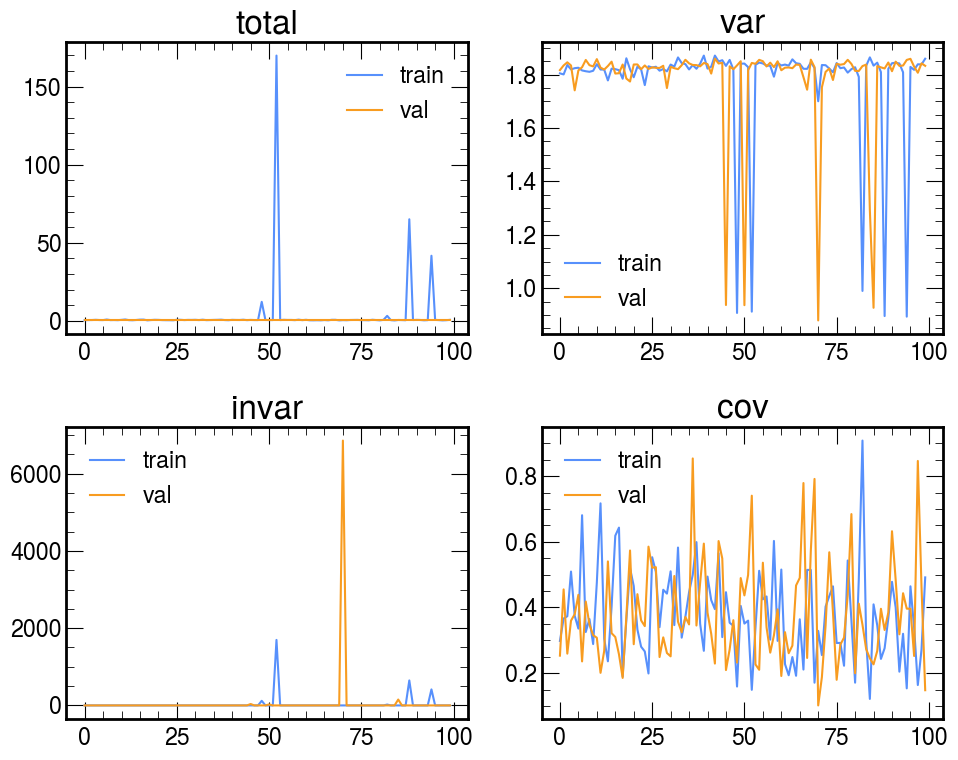

In [133]:
import matplotlib.pyplot as plt
# Create a figure
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
x = np.linspace(0, 10, 100)

# Plot 1
axs[0, 0].plot(train_loss_list["total"], label="train")
axs[0, 0].plot(val_loss_list["total"], label="val")
axs[0, 0].set_title('total')
axs[0, 0].legend()

# Plot 2
axs[0, 1].plot(train_loss_list["var"], label="train")
axs[0, 1].plot(val_loss_list["var"], label="val")
axs[0, 1].set_title('var')
axs[0, 1].legend()

# Plot 3
axs[1, 0].plot(train_loss_list["invar"], label="train")
axs[1, 0].plot(val_loss_list["invar"], label="val")
axs[1, 0].set_title('invar')
axs[1, 0].legend()

# Plot 4
axs[1, 1].plot(train_loss_list["cov"], label="train")
axs[1, 1].plot(val_loss_list["cov"], label="val")
axs[1, 1].set_title('cov')
axs[1, 1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

# Downstream training
Train an MLPF on top of (1) trained VICreg, and (2) a randomly initialized VICReg

# Results
Comparing the downstream results of randomly initialized VICReg against a trained VICReg